In [ ]:
import h5py
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from ptychozoon.enhance import ElementMap, FluorescenceDataset, Product, VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.settings import DeconvolutionEnhancementSettings
from ptychozoon.settings import InterpolationTypes
import logging
from chronos import plotting
from chronos.timer_utils import toggle_timer, clear_timer_globals

import sys
sys.path.append("/home/beams1/B222816/scripts/readMDA.py")
from readMDA import *

## Load data

In [ ]:

# get relevant xrf data
file_path = (
    "/net/micdata/data1/bnp/2023-1/Isaure_fly0085_for_SH/img.dat/bnp_fly0085.mda.h5"
)
with h5py.File(file_path, "r") as F:
    channel_names = [x.decode() for x in F["/MAPS/channel_names"][()]]
    element_maps = []
    for i, channel in enumerate(channel_names):
        element_maps += [
            ElementMap(channel, F["/MAPS/XRF_Analyzed/NNLS/Counts_Per_Sec"][i])
        ]
    xrf_pos_x = F["MAPS/x_axis"][()]
    xrf_pos_y = F["MAPS/y_axis"][()]
flourescence_in = FluorescenceDataset(element_maps)


# get ptycho data
file_path = "/net/micdata/data1/bnp/2023-1/Isaure_fly0085_for_SH/results/ML_recon/fly085/roi0_Ndp256/MLs_L1_p10_g1000_Ndp64_pc50_noModelCon_bg0.1_vp5_vi_mm/Niter1000.mat"
d = sio.loadmat(file_path)
pixel_size_m = d["p"]["dx_spec"][0][0][0][0]
probe = d["probe"][:, :, :, :].transpose([3, 2, 1, 0]) # opr
# probe = d["probe"][:, :, :, 0].transpose([2, 1, 0]) # no opr
opr_mode_weights = d["outputs"]["probe_evolution"][0][0].transpose()
probe = probe/np.sqrt(np.sum(np.abs(probe) ** 2))
ptycho_in = Product(
    # probe_positions=d["outputs"]["probe_positions"][0][0] * pixel_size_m,
    probe_positions=np.roll(d["outputs"]["probe_positions"][0][0] * pixel_size_m, 1) * 1,
    probe=probe,
    object_array=d["object"],
    pixel_size_m=(pixel_size_m,) * 2,
    object_center_m = np.array([0, 0]),
    opr_mode_weights=opr_mode_weights,
    # object_center_m=np.roll((np.array(d["object"].shape) / 2) * pixel_size_m, 0),
)

# get invalid indices
with h5py.File("/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/data_roi0_Ndp128_para.hdf5", "r") as F:
    valid_position_index = F["pos_index"][()]
xrf_shape = flourescence_in.element_maps[2].counts_per_second.shape
n_points = np.prod(xrf_shape)
invalid_position_index = [x for x in range(0, n_points) if x not in valid_position_index]


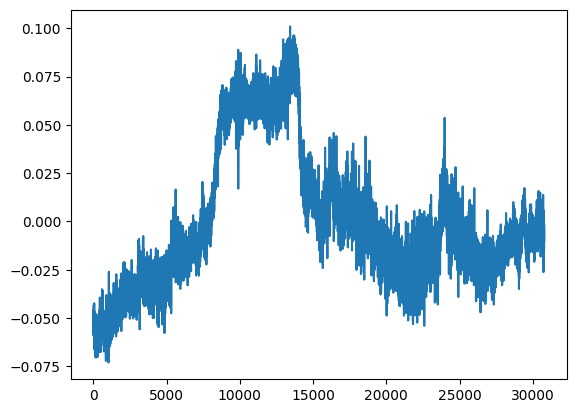

In [ ]:
plt.plot(opr_mode_weights[3])

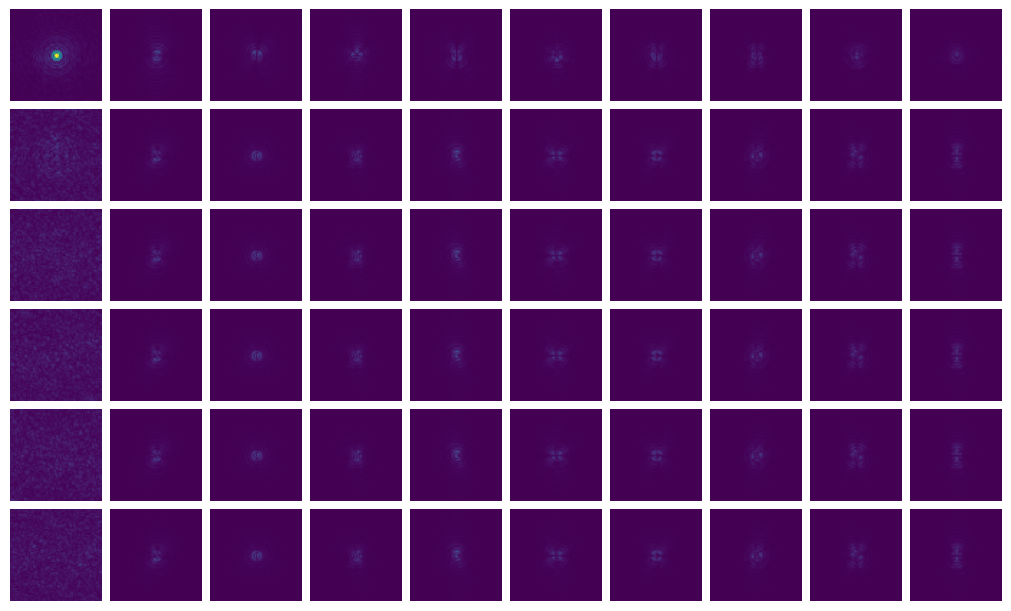

In [ ]:
fig, axs = plt.subplots(*probe.shape[:2], layout="compressed", figsize=(10,10))
for i in range(probe.shape[0]):
    for j in range(probe.shape[1]):
        plt.sca(axs[i,j])
        plt.imshow(np.abs(probe[i,j]))
        plt.clim([0, 0.1])
        plt.axis("off")

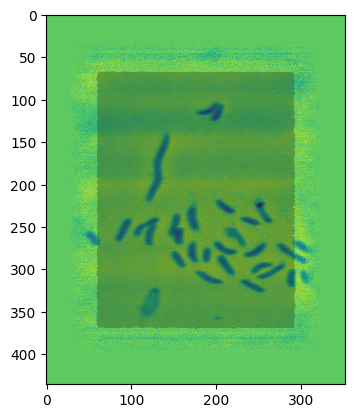

In [ ]:
plt.imshow(np.angle(ptycho_in.object_array))
plt.plot(
    (ptycho_in.probe_positions[:, 1]/pixel_size_m + ptycho_in.object_array.shape[1] / 2),
    (ptycho_in.probe_positions[:, 0]/pixel_size_m + ptycho_in.object_array.shape[0] / 2),
    "k",
    alpha=0.25,
)
plt.show()

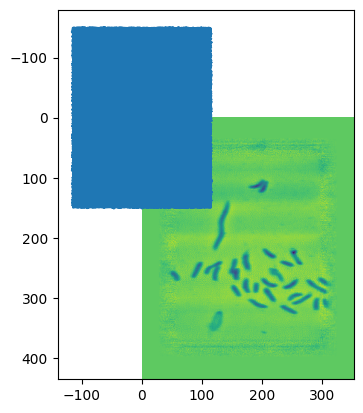

In [ ]:
plt.imshow(np.angle(ptycho_in.object_array))
plt.plot(ptycho_in.probe_positions[:, 1]/pixel_size_m, ptycho_in.probe_positions[:, 0]/pixel_size_m)
plt.show()

## test vspi

In [ ]:
import importlib
import ptychozoon
importlib.reload(ptychozoon)
importlib.reload(ptychozoon.enhance)
importlib.reload(ptychozoon.settings)

from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.settings import DeconvolutionEnhancementSettings

AttributeError: module 'ptychozoon' has no attribute 'enhance'

In [ ]:
settings = DeconvolutionEnhancementSettings()
settings.interpolation = InterpolationTypes.FOURIER
settings.solver = "lsmr"
settings.lsmr.max_iter = 100
settings.lsmr.damping_factor = 0
settings.lsmr.atol = 0
settings.lsmr.btol = 0

clear_timer_globals()
toggle_timer(True)
# logging.basicConfig(level=logging.DEBUG)
flourescence_result = VSPIFluorescenceEnhancingAlgorithm().enhance(
    flourescence_in,
    ptycho_in,
    valid_pixel_index=valid_position_index,
    select_maps=["K"],
    settings=settings,
)
# logging.basicConfig(level=0)

  0%|          | 0/1 [00:00<?, ?it/s]INFO:ptychozoon.enhance:Enhancing "K"...


(30777, 64, 64)


100%|██████████| 6/6 [00:00<00:00, 1267.61it/s]


(30777, 64, 64)


100%|██████████| 6/6 [00:00<00:00, 19108.45it/s]


...

100%|██████████| 6/6 [00:00<00:00, 5671.81it/s]


(30777, 64, 64)


100%|██████████| 6/6 [00:00<00:00, 6196.95it/s]
DEBUG:ptychozoon.enhance:Result: (array([0., 0., 0., ..., 0., 0., 0.], shape=(153908,)), 7, 10, np.float64(27.33326368700455), np.float64(4.352873294396198e-05), np.float64(5.807687461158293e-05), np.float64(150562.82140990885), 8204489.843977284)
DEBUG:ptychozoon.enhance:Number of iterations: 10
DEBUG:ptychozoon.enhance:norm(b-Ax): 27.33326368700455
DEBUG:ptychozoon.enhance:norm(A^H (b - Ax)): 4.352873294396198e-05
DEBUG:ptychozoon.enhance:norm(A)): 5.807687461158293e-05
INFO:ptychozoon.enhance:Enhanced "K" in 4.6618 seconds.
100%|██████████| 1/1 [00:04<00:00,  4.71s/it]


(30777, 64, 64)


100%|██████████| 6/6 [00:00<00:00, 18157.16it/s]


In [31]:
import importlib
import ptychozoon
importlib.reload(ptychozoon)
importlib.reload(ptychozoon.enhance)
from ptychozoon.enhance import _get_probe_intensity_at_each_position

a = _get_probe_intensity_at_each_position(ptycho_in.probe, ptycho_in.opr_mode_weights)

(30777, 64, 64)


100%|██████████| 6/6 [00:04<00:00,  1.40it/s]


(30777, 64, 64)


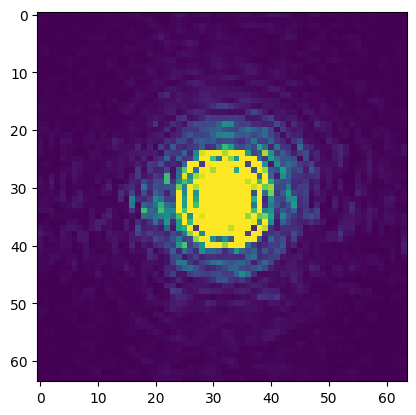

In [41]:
plt.imshow((np.abs(probe[0, :]) ** 2).sum(0))
plt.clim([0, 0.0001])

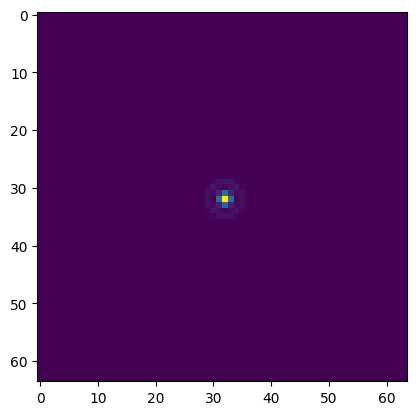

In [35]:
plt.imshow(a[0])
plt.show()

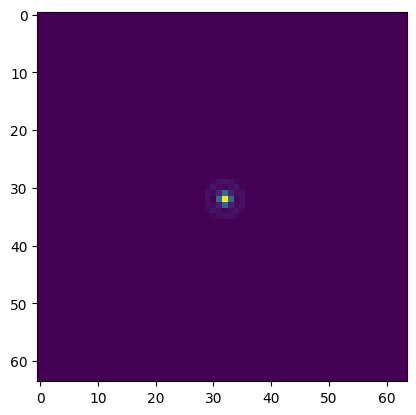

In [36]:
plt.imshow(a[100])
plt.show()

In [47]:
ptycho_in.probe[0].nbytes * 1e-9 * 30777

2.017001472

AttributeError: 'tuple' object has no attribute 'element_maps'

DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/beams/HRUTH/miniforge3/envs/ptychozoon/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizTwoSymBol.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/beams/HRUTH/miniforge3/envs/ptychozoon/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/cmmi10.ttf', name='cmmi10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/beams/HRUTH/miniforge3/envs/ptychozoon/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralItalic.ttf', name='STIXGeneral', style='italic', variant='normal', weight=400, stretch='normal', size='s

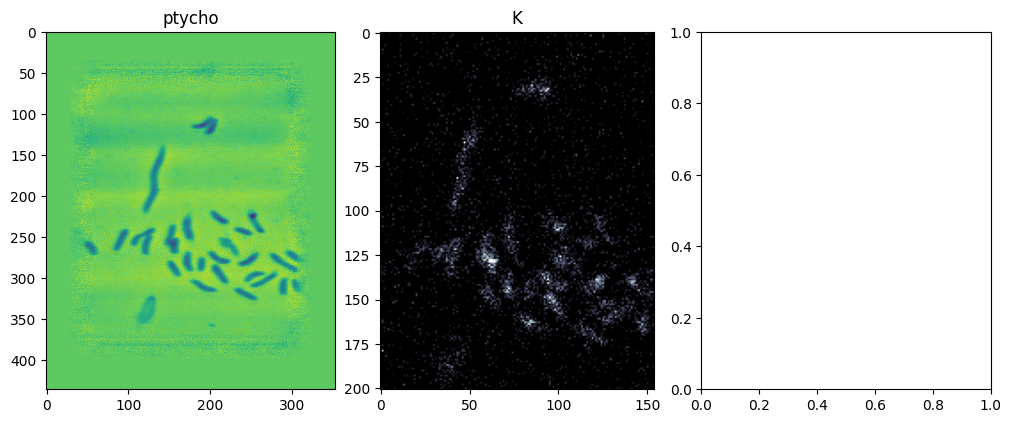

In [21]:
# 10 iterations, fourier
fig, ax = plt.subplots(1, 3, layout="compressed", figsize=(10, 10))
plt.sca(ax[0])
plt.title("ptycho")
plt.imshow(np.angle(ptycho_in.object_array))
plt.sca(ax[1])
idx = 5
plt.title(flourescence_in.element_maps[idx].name)
plt.imshow(flourescence_in.element_maps[idx].counts_per_second, cmap="bone")
plt.clim([0, 5])
plt.sca(ax[2])
plt.title(flourescence_result.element_maps[0].name)
plt.imshow(flourescence_result.element_maps[0].counts_per_second, cmap="bone")
plt.clim([0, 10])
plt.show()

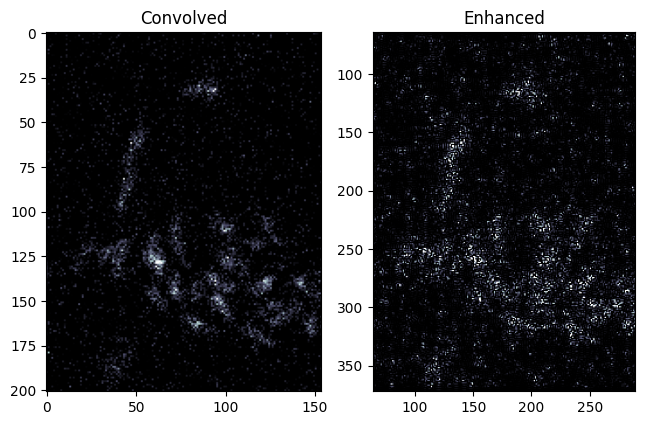

In [43]:
fig, ax = plt.subplots(1, 2, layout="compressed")
padding=64
i=5
plt.sca(ax[0])
arr = flourescence_in.element_maps[5].counts_per_second
plt.imshow(arr, cmap="bone")
plt.title("Convolved")
plt.clim([0, 5])
plt.sca(ax[1])
plt.title("Enhanced")
arr = flourescence_result.element_maps[0].counts_per_second
plt.imshow(arr, cmap="bone")
plt.xlim([padding, arr.shape[1]-padding])
plt.ylim([arr.shape[0]-padding, padding])
plt.clim([0, 20])
plt.show()

# Misc

### Make file with indexing results

In [2]:
#!/APSshare/anaconda/x86_64/bin/python
import h5py
import numpy as np
import os #for change directory
import scipy.io as sio #for read/write matlab file
from numpy import *
import time
import scipy.ndimage
import glob
import pdb

import sys
import csv


sys.path.append("/home/beams1/B222816/scripts")
from readMDA import *
import datetime

# scans=np.arange(95,1000,1)
scans = [85]
#scans=[41]
# user_dir='/mnt/micdata1/bnp/2023-1/Isaure/'
user_dir = '/net/micdata/data1/bnp/2023-1/Isaure/'
data_dir =user_dir+'ptycho/'
result_dir = user_dir+'results/ML_recon/fly{:03d}/'
#xrf_file = user_dir+'img.dat/bnp_fly{:04d}.mda.h5'
xrf_file = user_dir+'img.dat/bnp_fly{:04d}.mda.h5'
mda_file=user_dir+'mda/bnp_fly{:04d}.mda'



energy = 12.3
det_sample_dist = 2.0578
det_pixel_size = 75e-6
cen_x = 503
cen_y = 268
det_Npixel = 128
lam = 1.23984193e-9/energy
dx = lam*det_sample_dist/det_pixel_size/det_Npixel #pixel size
filePath = '/entry/data/data'
print("real-space pixel size: " + str(dx))

N_scan_x_lb = 0
N_scan_y_lb = 1
roi='0_Ndp' + str(det_Npixel)

# while True:
for scanNo in scans:
    
    data_dir_next = mda_file.format(scanNo)
    dataExist = os.path.isfile(data_dir_next)
    if not dataExist:
        print('Scan No.' + str(scanNo+1) + '-Data does not exist!')
        continue

    dataName = 'data_roi' + roi + '_dp.hdf5'
    dataExists = os.path.isfile(result_dir.format(scanNo)+dataName)
    if dataExists:
        print('Scan No.' + str(scanNo) + '-Data already exists!')
        continue    
    #pdb.set_trace()
    if not os.path.exists(result_dir.format(scanNo)): os.makedirs(result_dir.format(scanNo))
    print(result_dir.format(scanNo))

    #############Getting scan position############
    #XRFfile=h5py.File(xrf_file.format(scanNo))
    #x_pos=XRFfile['MAPS/x_axis'].value
    #y_pos=XRFfile['MAPS/y_axis'].value
    mda_data=readMDA(mda_file.format(scanNo))
    y_pos=np.array(mda_data[1].p[0].data) # HR uncomment
    y_pos=y_pos[np.argwhere(y_pos!=0.0)]  #incomplete scan shows 0 for unscanned lines
    x_pos=np.array(mda_data[2].p[0].data)[0]
    #pdb.set_trace()
    x_pos-=x_pos.mean()
    y_pos-=y_pos.mean()
    x_pos*=1e-6
    y_pos*=1e-6

    N_scan_x = x_pos.shape[0]
    print('X scan points: {:d}'.format(N_scan_x))
    N_scan_y = y_pos.shape[0]
    print('y scan points: {:d}'.format(N_scan_y))

    #############Loading diffraction patterns and poistions############
    scan_posx=0
    scan_posy=0 
    diffs=[]
    for i in range(N_scan_y-N_scan_y_lb):
        print("Iteration:", i)
        #fileName = data_dir+'fly{:03d}_data_{:06d}.h5'.format(scanNo,i+1+N_scan_y_lb)
        fileName = data_dir+'bnp_fly{:04d}_{:06d}.h5'.format(scanNo,i+N_scan_y_lb)        
        try:
            #pdb.set_trace()
            h5_data = h5py.File(fileName,'r')
            # dp_temp = h5_data[filePath].value # HR uncomment
            dp_temp = h5_data[filePath][()]
            dp_temp[dp_temp<0] = 0
            dp_temp[dp_temp>1e7] = 0
            print(fileName, dp_temp.shape)
            ith_line_N=dp_temp.shape[0]
            if ith_line_N<5:
                print('A lot of pixels are missed on this line:{:d}pxiels, Skip!'.fomrat(ith_line_N))
                continue
            if len(diffs)==0:
                # diffs=dp_temp[:,cen_y-det_Npixel/2:cen_y+det_Npixel/2,cen_x-det_Npixel/2:cen_x+det_Npixel/2] # HR uncomment
                diffs = dp_temp[:,cen_y-det_Npixel//2:cen_y+det_Npixel//2,cen_x-det_Npixel//2:cen_x+det_Npixel//2] # HR add
                scan_posx=x_pos[:ith_line_N]
                scan_posy=np.ones(ith_line_N)*y_pos[i+N_scan_y_lb]
            else:
                # diffs=np.append(diffs,dp_temp[:,cen_y-det_Npixel/2:cen_y+det_Npixel/2,cen_x-det_Npixel/2:cen_x+det_Npixel/2],axis=0)
                diffs=np.append(diffs,dp_temp[:,cen_y-det_Npixel//2:cen_y+det_Npixel//2,cen_x-det_Npixel//2:cen_x+det_Npixel//2],axis=0)
                scan_posx=np.append(scan_posx,x_pos[:ith_line_N])
                scan_posy=np.append(scan_posy,np.ones(ith_line_N)*y_pos[i+N_scan_y_lb])
            h5_data.close()
        except:
            print("Has problem with opening file: {:s}".format(fileName))
            break
            # pass

    dp_sum=np.sum(diffs,axis=(1,2))
    #pdb.set_trace()
    pos_index=np.argwhere(dp_sum>(dp_sum.mean()/1.08))
    diffs=diffs[pos_index[:,0]]
    scan_posx=scan_posx[pos_index[:,0]]
    scan_posy=scan_posy[pos_index[:,0]]
    #print scan_posx.shape[0]
    #print scan_posy.shape[0]
    print(len(diffs))
    ##################### save data ##########################
    # print("saving " + 'data_roi' + roi + '.hdf5' + " to " + result_dir.format(scanNo))
    # f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_dp.hdf5', "w")
    # f.create_dataset("dp", dtype='float64', data=diffs, compression="gzip")
    # #f.create_dataset("dp", data=diffs, compression="gzip")
    # f.close()
    # #save other parameters
    # f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_para.hdf5', "w")
    # f.create_dataset("lambda", shape=(1,),dtype='float64', data=lam)
    # f.create_dataset("dx", shape=(1,),dtype='float64', data=dx)
    # f.create_dataset("ppY", dtype='float64', data=scan_posy)
    # f.create_dataset("ppX", dtype='float64', data=scan_posx)

    # f.create_dataset("N_scan_y_lb", shape=(1,),dtype='int', data=N_scan_y_lb)
    # f.create_dataset("N_scan_x_lb", shape=(1,),dtype='int', data=N_scan_x_lb)
    # f.create_dataset("N_scan_y", shape=(1,),dtype='int', data=N_scan_y)
    # f.create_dataset("N_scan_x", shape=(1,),dtype='int', data=N_scan_x)
    # f.close()
# time.sleep(5)


real-space pixel size: 2.1606933634434283e-08
/net/micdata/data1/bnp/2023-1/Isaure/results/ML_recon/fly085/
/net/micdata/data1/bnp/2023-1/Isaure/mda/bnp_fly0085.mda is a 2-D file; 2 dimensions read in.
dim[0] = dictionary of 42 scan-environment PVs
   usage: dim[0]['sampleEntry'] -> ('description', 'unit string', 'value')
dim[1] = 1D data from "9idbBNP:scan2": 201/201 pts; 4 pos's, 6 dets, 3 trigs
dim[2] = 2D data from "9idbBNP:scan1": 154/154 pts; 1 pos's, 42 dets, 2 trigs
   usage: dim[1].p[2].data -> 1D array of positioner 2 data
   usage: dim[2].d[7].data -> 2D array of detector 7 data
X scan points: 154
y scan points: 201
Iteration: 0
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_000001.h5 (154, 1062, 1028)
Iteration: 1
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_000002.h5 (154, 1062, 1028)
Iteration: 2
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_000003.h5 (154, 1062, 1028)
Iteration: 3
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_00000

In [5]:
result_dir = "/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/"

print("saving " + 'data_roi' + roi + '.hdf5' + " to " + result_dir.format(scanNo))
f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_dp.hdf5', "w")
f.create_dataset("dp", dtype='float64', data=diffs, compression="gzip")
#f.create_dataset("dp", data=diffs, compression="gzip")
f.close()

saving data_roi0_Ndp128.hdf5 to /local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/


In [23]:
#save other parameters
print("save other params")
f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_para.hdf5', "w")
f.create_dataset("lambda", shape=(1,),dtype='float64', data=lam)
f.create_dataset("dx", shape=(1,),dtype='float64', data=dx)
f.create_dataset("ppY", dtype='float64', data=scan_posy)
f.create_dataset("ppX", dtype='float64', data=scan_posx)

f.create_dataset("N_scan_y_lb", shape=(1,),dtype='int', data=N_scan_y_lb)
f.create_dataset("N_scan_x_lb", shape=(1,),dtype='int', data=N_scan_x_lb)
f.create_dataset("N_scan_y", shape=(1,),dtype='int', data=N_scan_y)
f.create_dataset("N_scan_x", shape=(1,),dtype='int', data=N_scan_x)

f.create_dataset("pos_index", dtype='int', data=[x[0] for x in pos_index])

f.close()

save other params


### Get invalid indices

In [ ]:
# load 
with h5py.File("/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/data_roi0_Ndp128_para.hdf5", "r") as F:
    valid_position_index = F["pos_index"][()]
xrf_shape = flourescence_in.element_maps[2].counts_per_second.shape
n_points = np.prod(xrf_shape)
invalid_position_index = [x for x in range(0, n_points) if x not in valid_position_index]
# invalid_coords = np.unravel_index(
#     invalid_position_index, xrf_shape
# )


#### <misc>

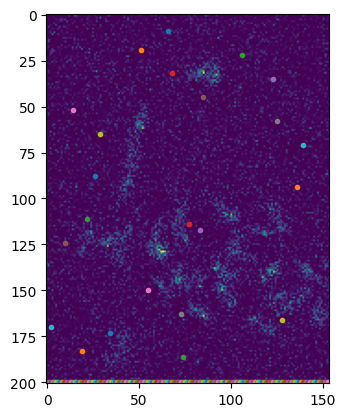

In [62]:
a = flourescence_in.element_maps[2].counts_per_second
plt.imshow(a)
n = len(invalid_coords[0])
for i in range(n):
    plt.plot(invalid_coords[1][i], invalid_coords[0][i], '.')
plt.show()

In [71]:
i=30
flourescence_in.element_maps[2].counts_per_second[invalid_coords[0][i], invalid_coords[1][i]]

np.float32(0.0)

In [74]:
np.where(flourescence_in.element_maps[2].counts_per_second==0)[0]

array([  0,   0,   0, ..., 200, 200, 200], shape=(7610,))

In [ ]:
# load 
with h5py.File("/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/data_roi0_Ndp128_para.hdf5", "r") as F:
    valid_position_index = F["pos_index"][()]

In [36]:
np.unravel_index(
    valid_position_index, flourescence_in.element_maps[2].counts_per_second.shape
)


(array([  0,   0,   0, ..., 199, 199, 199], shape=(30777,)),
 array([  0,   1,   2, ..., 151, 152, 153], shape=(30777,)))

In [63]:
ptycho_in.probe_positions.shape

(30777, 2)

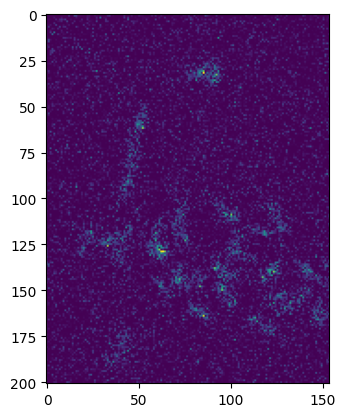

In [42]:
plt.imshow(flourescence_in.element_maps[2].counts_per_second)
plt.show()

In [45]:
np.prod(flourescence_in.element_maps[2].counts_per_second.shape)

np.int64(30954)

In [37]:
flourescence_in.element_maps[2].counts_per_second[valid_position_index]

IndexError: index 201 is out of bounds for axis 0 with size 201